In [14]:
!pip -q install numpy scipy matplotlib tftb


# Choose data

In [109]:
ae = "05"    # along horizontal axis
fz = "0150"  # along vertical axis

# Load data and signal

### Load libraries

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from pathlib import Path

#print(Path.cwd())

### Function for loading matlab files
Create a function for easy loading of files. Loading all at once with names maintained seems tricky, so we will go with this solution now.

In [43]:
def load_matfile(ae, fz):
    folder = Path("DBS900_F01_Acc34_PreProc26")
    filename = f"preproc_DBS900_F01_ae{ae}_fz{fz}.mat"
    mat_file = folder / filename
    if mat_file.exists():
        mat = loadmat(mat_file)
        print(f"Loaded file: {filename}")
        return mat
    else:
        print(f"File {filename} not found.")
        return None 


Testing the loader. 'loadmat()' returns a dictionary, which here has the keys: 
'__header__', 
'__version__', 
'__globals__', 
'R1' = Renyi entropy 1, 367 values, 
'R2' = Renyi entropy 2, 367 values, 
'TI' = 367 values from 0 to 60,
'T_begin' = start of milling,
'T_end' = end of milling, 
'Td' = time vector (s), 1,200,000 values from 0 to 60, 
'acc1f' = accelerometer 1, 
'acc2f' = accelerometer 2, 
'fsd' = 20,000 = sampling frequency after downsampling

### Load signal data

In [110]:
data = load_matfile(ae, fz)

acc1 = data["acc1f"].squeeze()
acc2 = data["acc2f"].squeeze()
signals = [acc1, acc2]

Td = data["Td"].T.squeeze()
fs = data["fsd"].squeeze()

T_begin = data["T_begin"].squeeze()
T_end = data["T_end"].squeeze()


Loaded file: preproc_DBS900_F01_ae05_fz0150.mat


### Plot signal from accelerometer 1 and 2

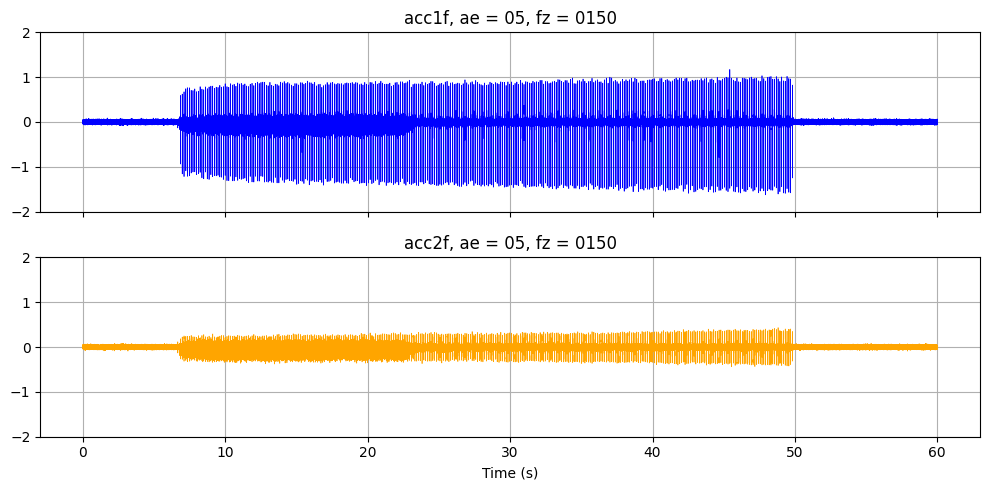

In [111]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

axes[0].plot(Td, acc1, linestyle="-", linewidth=0.5, color="blue")
axes[0].set_title(f"acc1f, ae = {ae}, fz = {fz}")
axes[0].grid(True)
axes[0].set_ylim([-2, 2])

axes[1].plot(Td, acc2, linestyle="-", linewidth=0.5, color="orange")
axes[1].set_title(f"acc2f, ae = {ae}, fz = {fz}")
axes[1].grid(True)
axes[1].set_ylim([-2, 2])

axes[1].set_xlabel("Time (s)")


plt.tight_layout()
plt.show()

# Preprocessing

### Trim the accelerometer data and time vector

In [47]:
def trim_by_time(signal, Td, T_begin, T_end):
    mask = (Td >= T_begin) & (Td <= T_end)
    return signal[mask], Td[mask]

acc1_trimmed, Td_trimmed = trim_by_time(acc1, Td, T_begin, T_end)
acc2_trimmed, _ = trim_by_time(acc2, Td, T_begin, T_end)

### Function for switching between trimmed and non-trimmed

In [122]:
signals = {
    "raw": [acc1, acc2],
    "trimmed": [acc1_trimmed, acc2_trimmed]
}

def get_signals(kind = "raw"):
    return signals[kind]

## Spectrogram (STFT) with multiple window lengths
- Short window -> good time resolution, but smeared frequency.
- Long window -> bad time resolution (smeared), good frequency resolution

### Function for plotting spectrograms

In [167]:
from scipy.signal import stft, get_window
import warnings


def plot_spectrogram(x,  
                     nperseg,        # Window length in samples (integer) 
                     fs = 1, 
                     noverlap=None,  # Number of samples to overlap between segments (integer, default: nperseg//2)
                     title="", 
                     plot_dB = True, # Should we plot in dB or linear scale?
                     dyn_range_db = 60,     # Dynamic range to cut low power noise in dB for display (ignored if plot_dB=False)
                     nfft=2048,      # Number of FFT points (default: 2048, can be larger than nperseg for zero-padding)
                     normalized_dB = True): # Should the spectrogram be normalized to its maximum value (0 dB) for display?:
    if noverlap is None:             # If no overlap is specified, use half the window length
        noverlap = nperseg//2
    
    if 0 < noverlap < 1:             # If noverlap is a fraction, convert to samples
        noverlap = int(round(noverlap * nperseg))
    if noverlap >= nperseg:
        warnings.warn(
            "noverlap>=nperseg is not allowed, setting noverlap = nperseg-1",
            RuntimeWarning
        )
        noverlap = nperseg - 1

    # Hann reduces spectral leakage and is said to be standard for spectrograms
    w = get_window("hann", nperseg, fftbins=False) # fftbins=False to get a symmetric window (not periodic), 
    # which is more appropriate for spectrograms (no FFT symmetry) 
    
    # Compute the STFT
    f, t, Z = stft(x, 
                   fs=fs, 
                   window=w, 
                   nperseg=nperseg, 
                   noverlap=noverlap,
                   nfft=nfft, 
                   boundary=None, 
                   padded=False, 
                   return_onesided=True) # =True for analytic signals (no negative frequencies)


    P = np.abs(Z)**2 # Power dB 

    if plot_dB:
        if normalized_dB:
            P = P/(np.max(P)+1e-20)  # Normalize to max power
        S = 10*np.log10(P+1e-20)     # Convert to dB, add small constant to avoid log(0)
        cbar = "Power (dB, rel. max)"
    else:       
        S = P # Linear scale
        cbar = "Power (linear)"
    Smax = np.max(S)
    

    if plot_dB and dyn_range_db is not None:
        Smin = Smax - dyn_range_db
    else:
        Smin = np.min(S)

        
    plt.figure(figsize=(10,4))
    plt.pcolormesh(t, f, S, shading="auto", vmin= Smin, vmax = Smax)
    plt.ylim(0, fs/2)  # analytic: positive freqs
    if fs==1:
         plt.ylim(0, 0.5)  # normalized freqs
         plt.ylabel("Frequency (cycles/sample)")
         plt.xlabel("Time (samples)")
    else:
        plt.ylabel("Frequency (Hz)")
        plt.xlabel("Time (s)")
    plt.title(title + f"  (nperseg={nperseg}, noverlap={noverlap} samples)")
    plt.colorbar(label=cbar)
    plt.tight_layout()

    return f, t, S
#x0 = X[0]
#for L in [2, 4, 8, 16, 32, 64, 128]:
#    plot_spectrogram(x0, nperseg=L, title="Spectrogram")


### Analysing the provided data with spectrogram


(0.0, 5000.0)

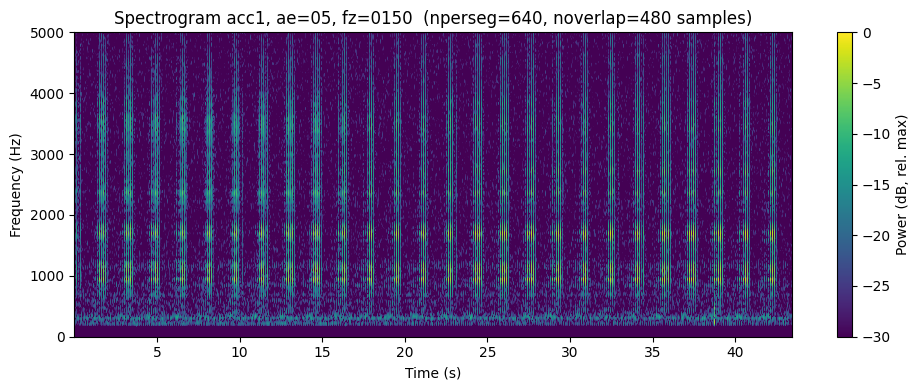

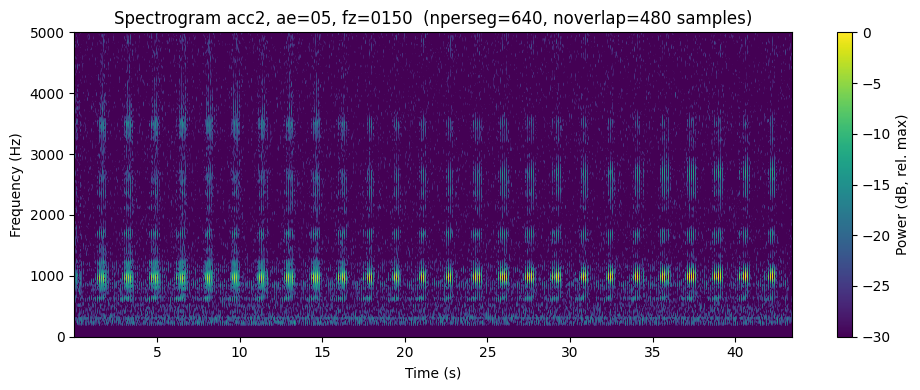

In [170]:
nperseg = 64 * 10 # Window length for Hann window 
nfft = 4 * nperseg # Number of FFT points (can be larger than nperseg for zero-padding, which gives smoother spectrograms)
signal_to_plot = get_signals("trimmed")
    
dyn_range_db = 30

plot_spectrogram(signal_to_plot[0], nperseg=nperseg, noverlap=int(0.75*nperseg), 
                 fs = fs, dyn_range_db=dyn_range_db, nfft = nfft, 
                 title=f"Spectrogram acc1, ae={ae}, fz={fz}",
                 normalized_dB=True)
plt.ylim(0, 5000)
    
plot_spectrogram(signal_to_plot[1], nperseg=nperseg, noverlap=int(0.75*nperseg), 
                 fs = fs, dyn_range_db=dyn_range_db, nfft = nfft, 
                 title=f"Spectrogram acc2, ae={ae}, fz={fz}",
                 normalized_dB=True)
plt.ylim(0, 5000)


# Multitaper spectrogram

### Function definition

In [ ]:
from scipy.signal.windows import dpss

def multitaper_spectrogram(
    x,
    fs,
    nperseg,
    noverlap=None,
    nfft=None,
    NW=3.5,          # time-bandwidth product
    Kmax=None,       # number of tapers; default uses int(2*NW)-1
    detrend=False,
    boundary=None,   # avoid padding for long signals; set to None
    padded=False,
    onesided=True,
    dyn_range_db=60,
    title="Multitaper spectrogram",
    fmin = None,
    fmax = None
):
    x = np.asarray(x).squeeze()

    if noverlap is None:             # If no overlap is specified, use half the window length
            noverlap = nperseg//2
        
    if 0 < noverlap < 1:             # If noverlap is a fraction, convert to samples
        noverlap = int(round(noverlap * nperseg))
    if noverlap >= nperseg:
        warnings.warn(
            "noverlap>=nperseg is not allowed, setting noverlap = nperseg-1",
            RuntimeWarning
        )
        noverlap = nperseg - 1

    if nfft is None:
        nfft = nperseg

    if Kmax is None:
        Kmax = max(1, int(2*NW) - 1)

    # DPSS tapers: shape (Kmax, nperseg)
    tapers, eigvals = dpss(nperseg, NW, Kmax=Kmax, return_ratios=True) # Return the eigenvalues (concentration ratios) for potential weighting (not used here, but could be in a more advanced version)

    S_accum = None
    for k in range(Kmax):
        w = tapers[k]

        f, t, Z = stft(
            x,
            fs=fs,
            window=w,
            nperseg=nperseg,
            noverlap=noverlap,
            nfft=nfft,
            detrend=False if detrend is False else detrend,
            return_onesided=onesided,
            boundary=boundary,
            padded=padded
        )

        Pk = np.abs(Z)**2  # power
        if S_accum is None:
            S_accum = Pk
        else:
            S_accum += eigvals[k] * Pk

    S = S_accum / np.sum(eigvals)  # average linear power (multitaper estimate)
    S_norm = S / (np.max(S) + 1e-20)  # normalize to max power for display
    S_db_norm = 10*np.log10(S_norm + 1e-20)

    vmax = 0 # I already normalized to max power, so 0 dB corresponds to the max
    vmin = - dyn_range_db



    plt.figure(figsize=(10, 4))
    plt.pcolormesh(t, f, S_db_norm, shading="auto", vmin=vmin, vmax=vmax)
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(f"{title}  (nperseg={nperseg}, noverlap={noverlap}, NW={NW}, K={Kmax})")
    plt.colorbar(label="Power (dB, rel. max)")
    plt.tight_layout()

    return f, t, S, S_db_norm

### Function call

(0.0, 60.0)

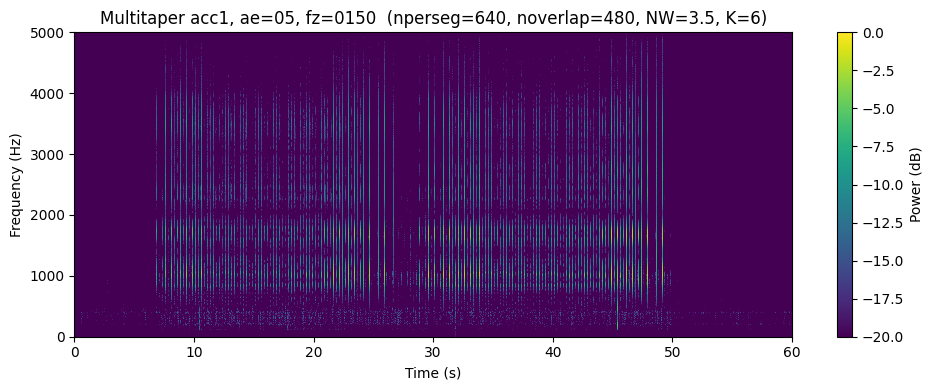

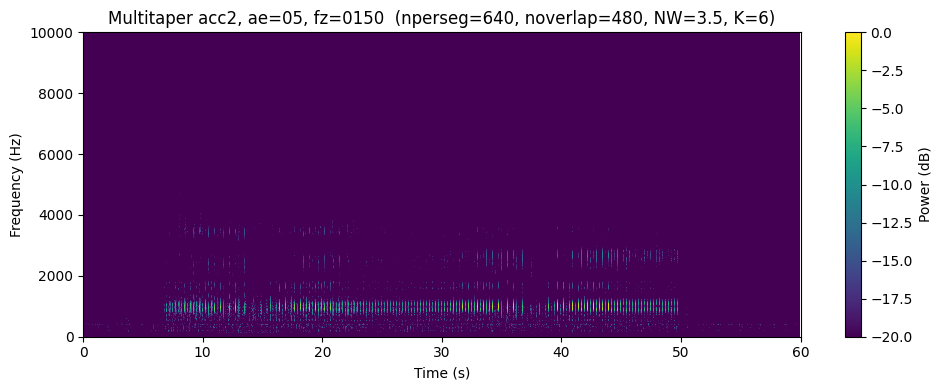

In [183]:

nperseg = 64 * 10 # Window length for Hann window 
nfft = 4 * nperseg # Number of FFT points (can be larger than nperseg for zero-padding, which gives smoother spectrograms)
signal_to_plot = get_signals("raw")
dyn_range_db = 20

start_window = 0
stop_window = 60
time_hop = 0

f, t, S, S_db = multitaper_spectrogram(
    signal_to_plot[0], fs=fs,
    nperseg=nperseg, noverlap = int(0.75*nperseg), nfft = nfft,
    NW=3.5, dyn_range_db=dyn_range_db, 
    title=f"Multitaper acc1, ae={ae}, fz={fz}"
)
plt.xlim(start_window + time_hop, stop_window + time_hop)   # pick any region inside milling
plt.ylim(0, 5000)

f, t, S, S_db = multitaper_spectrogram(
    signal_to_plot[1], fs=fs,
    nperseg=nperseg, noverlap = int(0.75*nperseg), nfft = nfft,
    NW=3.5, dyn_range_db=dyn_range_db, 
    title=f"Multitaper acc2, ae={ae}, fz={fz}"
)
plt.xlim(start_window + time_hop, stop_window + time_hop)   # pick any region inside milling

# Clip the signals into revolutions

# Wigner-Ville and smoothed pseudo-WVD
Sharper TF, but cross-terms

### Function for plotting TFTB distributions


In [22]:
import numpy as np
import matplotlib.pyplot as plt

def plot_tfreq(
    tfr,
    title="",
    mode="signed",          # "signed" (real, i.e. +/-), "magnitude" (abs), "power_db"
    clip="percentile",      # "percentile" or "fixed"
    p=(1, 99),              # percentiles for robust clipping
    vmin=None, vmax=None,   # for clip="fixed"
    dr_db=60,               # dB dynamic range if mode="power_db"
    extent=(0, 256, 0, 0.5),
    interpolation="nearest",
    figsize=(9,4),
    colorbar_label=None,
):
    """
    High-quality plotting for WVD/PWVD/SPWVD/ambiguity.

    mode:
      - "signed": plots real(tfr) (WVD-like; preserves negative values)
      - "magnitude": plots abs(tfr)
      - "power_db": 10log10(|tfr|^2) with dB clipping (like a spectrogram)
    """
    tfr = np.asarray(tfr)

    if mode == "signed":
        A = np.real(tfr)
        default_cbar = "Real value"
    elif mode == "magnitude":
        A = np.abs(tfr)
        default_cbar = "Magnitude"
    elif mode == "power_db":
        P = (np.abs(tfr)**2)
        A = 10*np.log10(P + 1e-12)
        default_cbar = "Power (dB)"
    else:
        raise ValueError("mode must be 'signed', 'magnitude', or 'power_db'")

    # Choose color limits
    if mode == "power_db":
        amax = np.max(A)
        vmin_use = amax - dr_db
        vmax_use = amax
    else:
        if clip == "percentile":
            vmin_use = np.percentile(A, p[0]) if vmin is None else vmin
            vmax_use = np.percentile(A, p[1]) if vmax is None else vmax
            # If signed, make symmetric limits (looks better)
            if mode == "signed":
                m = max(abs(vmin_use), abs(vmax_use))
                vmin_use, vmax_use = -m, m
        elif clip == "fixed":
            if vmax is None:
                vmax_use = np.max(A)
            else:                
                vmax_use = vmax
            if vmin is None:
                vmin_use = vmax_use - dr_db
            else:
                vmin_use = vmin

        
    plt.figure(figsize=figsize)
    plt.imshow(
        A,
        aspect="auto",
        origin="lower",
        extent=extent,
        vmin=vmin_use,
        vmax=vmax_use,
        interpolation=interpolation,
    )
    plt.xlabel("Time (samples)")
    plt.ylabel("Frequency (cycles/sample)")
    plt.title(f"{title}, mode={mode}, clip={clip}")
    plt.colorbar(label=(colorbar_label or default_cbar))
    plt.tight_layout()

## Wigner-Ville and pseudo-WV

WVD is quadratic in N, which means it will try to allocate 1.2M^2 = 1.44*10^12 complex numbers = 21 TiB. So we must do something else.

In [23]:
from tftb.processing.cohen import WignerVilleDistribution, PseudoWignerVilleDistribution
from scipy.signal.windows import hann

fwin = hann(255)

for  i, signal in enumerate(signals, start=1):

    wvd = WignerVilleDistribution(signal)
    tfr_wvd, _, _ = wvd.run()
    plot_tfreq(tfr_wvd, 
               title = f"Wigner–Ville for acc{i}, ae={ae}, fz={fz}", 
               mode = "signed", 
               clip = "percentile",
               p = (2, 98))
    #plt.savefig(f"plots/wvd_{i}.png", dpi = 300, bbox_inches = "tight")
    #plt.close()

    pwvd = PseudoWignerVilleDistribution(signal, fwindow = fwin)
    tfr_pwvd, _, _ = pwvd.run()
    plot_tfreq(tfr_pwvd, 
               title = f"Pseudo-WVD for acc{i}, ae={ae}, fz={fz}", 
               mode = "signed", 
               clip = "percentile",
               p = (2, 98))
    #plt.savefig(f"plots/pwvd_{i}.png", dpi = 300, bbox_inches = "tight")
    #plt.close()


MemoryError: Unable to allocate 21.0 TiB for an array with shape (1200000, 1200000) and data type complex128

## Reassigned spectrogram

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import gaussian
from tftb.processing import reassigned_spectrogram


def plot_reassigned(x, n_fbins=256, win_len=63, dyn_range_db=35,
                         title="Reassigned spectrogram"):

    x = np.asarray(x).squeeze()
    N = len(x)

    # Ensure odd window length as it as a clean "center sample"
    if win_len % 2 == 0:
        win_len += 1

    win = gaussian(win_len, std=win_len/6, sym=False) # sigma smaller -> better time resolution, worse frequency resolution

    tfr, rtfr, _ = reassigned_spectrogram(
        x,
        time_samples=np.arange(N),
        n_fbins=n_fbins,
        window=win
    )

    f = np.linspace(0, 0.5, n_fbins, endpoint=False) # if rtfr.shape[0]==nbins, you are consistent on cound
    t = np.arange(N)

    P = np.abs(rtfr)**2
    P_db = 10*np.log10(P + 1e-12)

    vmax = P_db.max()
    vmin = vmax - dyn_range_db

    # Plotting
    plt.figure(figsize=(9, 4))
    plt.imshow(P_db, origin="lower", aspect="auto",
               extent=[t[0], t[-1], f[0], f[-1]],
               vmin=vmin, vmax=vmax)
    plt.xlabel("Time (samples)")
    plt.ylabel("Frequency (cycles/sample)")
    plt.title(f"{title}")
    plt.colorbar(label="dB")
    plt.tight_layout()
   
    return tfr, rtfr


In [26]:
for i, signal in enumerate(signals, start=1):
    _, rtfr = plot_reassigned(signal, win_len=255, dyn_range_db=30, title=f"Reassigned spectrogram for realization {i}")
    plt.savefig(f"plots/reassigned_{i}.png", dpi = 300, bbox_inches = "tight")
    #plt.close()

    P = np.abs(rtfr)**2
    ridge_idx = np.argmax(P, axis=0)
    f_axis = np.linspace(0, 0.5, P.shape[0], endpoint=False)
    ridge = f_axis[ridge_idx]
    plt.figure(figsize=(9,4))
    plt.plot(ridge)
    plt.ylim(0,0.5)
    plt.title(f"Dominant frequency over time for realization {m}")
    plt.savefig(f"plots/dominant_frequency_{m}.png", dpi = 300, bbox_inches = "tight")
    #plt.close()

/home/johannes/Documents/Lund_University/MASM26 - Spectral Analysis/project/.venv/lib/python3.12/site-packages/tftb/processing/reassigned.py:543: ComplexWarning: Casting complex values to real discards the imaginary part
  rtfr[int(jcolhat), int(icolhat) - 1] += tfr[jcol, icol]


KeyboardInterrupt: 

## Reassigned spectrogram with dominant frequency 

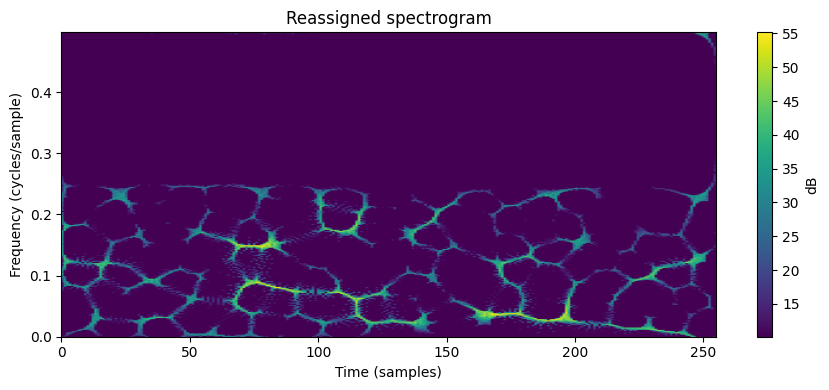

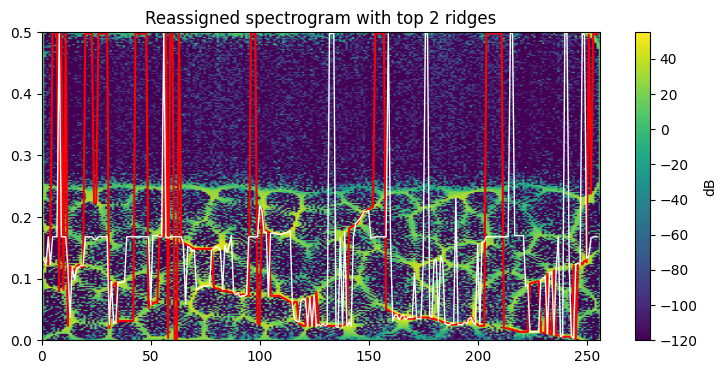

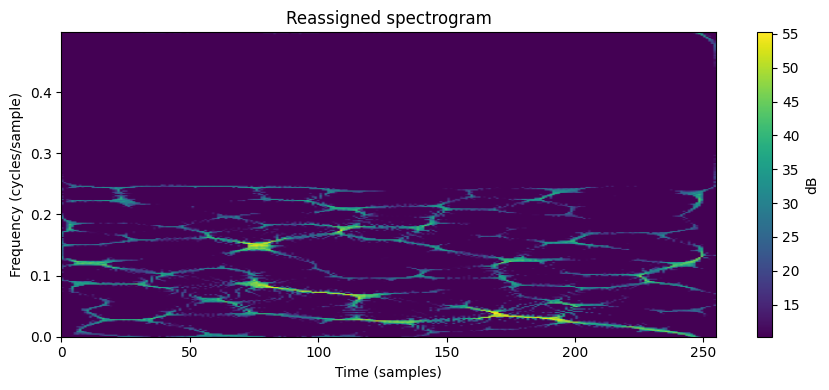

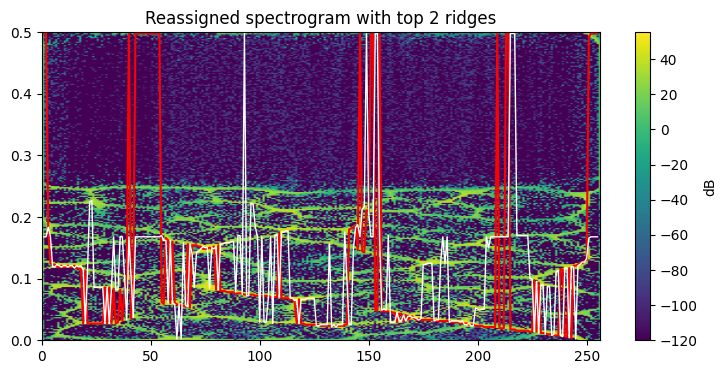

In [136]:
for wl in [31, 63]:

    _, rtfr0 = plot_reassigned(X[3], win_len=wl, dyn_range_db=45)

    P = np.abs(rtfr0)**2
    f_axis = np.linspace(0, 0.5, P.shape[0], endpoint=False)

    threshold = 0.01 * P.max()   # e.g. 1% of max energy
    P_masked = np.where(P > threshold, P, 0)

    # Get indices of top 2 bins per column
    top2_idx = np.argpartition(P_masked, -2, axis=0)[-2:, :]   # shape (2, N)

    # Now sort those two by power so first row is strongest
    col_indices = np.arange(P.shape[1])
    top2_power = P_masked[top2_idx, col_indices]
    order = np.argsort(top2_power, axis=0)

    top1_idx = top2_idx[order[1, :], col_indices]
    top2_idx = top2_idx[order[0, :], col_indices]

    ridge1 = f_axis[top1_idx]
    ridge2 = f_axis[top2_idx]

    plt.figure(figsize=(9,4))
    plt.imshow(10*np.log10(P + 1e-12), origin="lower", aspect="auto",
            extent=[0, len(ridge1), 0, 0.5])
    plt.plot(ridge1, color="red", linewidth=1.5)
    plt.plot(ridge2, color="white", linewidth=1.0)
    plt.ylim(0,0.5)
    plt.title("Reassigned spectrogram with top 2 ridges")
    plt.colorbar(label="dB")
    plt.show()

## Thomson multitaper spectral estimation of stationary process

In [352]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import dpss
from scipy.signal import lfilter

def ar_from_poles(poles):
    # Build A(q)=Π(1 - p q), q = z^{-1}  -> coefficients [a0..ap]
    a = np.array([1.0], dtype=complex)
    for p in poles:
        a = np.convolve(a, np.array([1.0, -p], dtype=complex))
    a = np.real_if_close(a, tol=1e6).astype(float)
    return a  # length 5 for AR(4): a[0]=1

def simulate_ar(a, sigma_e, N, burn=500):
    # x = filter(1, A(z)) e  where A(z)=sum a_k z^{-k}
    e = sigma_e * np.random.randn(N + burn)
    x = lfilter([1.0], a, e)
    return x[burn:]  # discard transient

def thomson_multitaper_psd(x, B, nfft=None):
    """
    x: length N
    B: bandwidth as in handout (interpreted as full bandwidth, so W=B/2)
    """
    N = len(x)
    if nfft is None:
        nfft = 1 << int(np.ceil(np.log2(N)))

    # Map handout B -> DPSS NW with W=B/2
    NW = N * B / 2.0
    K = int(np.floor(N * B - 2))
    K = max(K, 1)

    tapers = dpss(N, NW, Kmax=K, sym=False)  # shape (K, N)

    # FFT of tapered sequences
    Xk = np.fft.rfft(tapers * x[None, :], n=nfft, axis=1)
    Sk = np.abs(Xk) ** 2
    S = Sk.mean(axis=0)  # average over k

    f = np.fft.rfftfreq(nfft, d=1.0)  # cycles/sample, [0..0.5]
    return f, S, K, NW

def true_psd_ar(a, sigma_e, f):
    # A(e^{j2πf}) = sum_{k=0}^p a_k e^{-j2π f k}
    k = np.arange(len(a))
    A = np.sum(a[None, :] * np.exp(-1j * 2 * np.pi * f[:, None] * k[None, :]), axis=1)
    return (sigma_e**2) / (np.abs(A) ** 2)


B1=0.100 -> NW=25.60, K=49
B2=0.050 -> NW=12.80, K=23


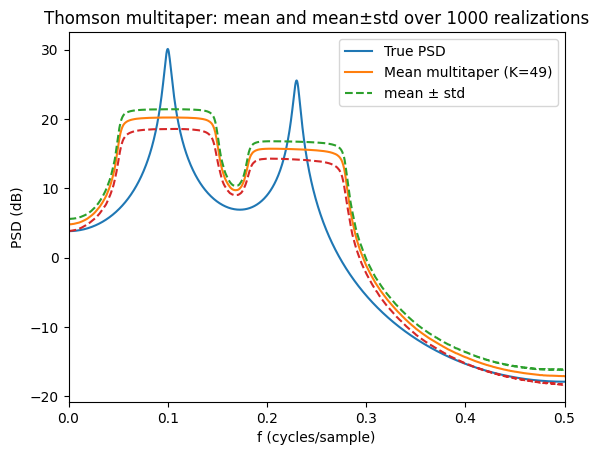

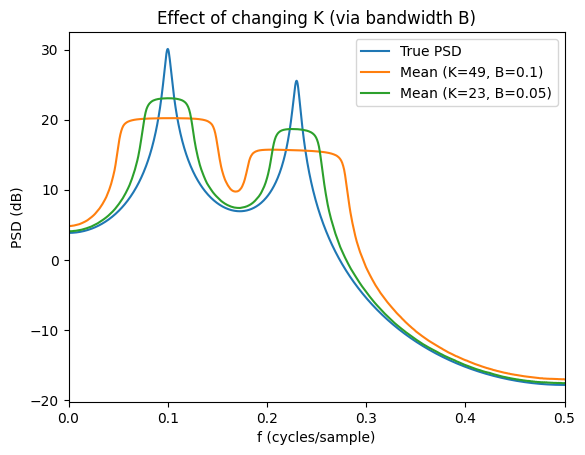

In [353]:

# -------------------------
# Parameters you can tweak
# -------------------------
np.random.seed(0)

N = 512                 # window length / sample size per realization
M = 1000                # number of realizations
sigma_e = 1.0

r = 0.98
f1, f2 = 0.10, 0.23     # cycles/sample (peaks near here)
poles = [r*np.exp(1j*2*np.pi*f1), r*np.exp(-1j*2*np.pi*f1),
         r*np.exp(1j*2*np.pi*f2), r*np.exp(-1j*2*np.pi*f2)]
a = ar_from_poles(poles)

nfft = 2048
B1 = 0.10               # handout bandwidth (full bandwidth), try 0.06..0.15
B2 = 0.05               # second bandwidth to change K (half of B1 here)

def run_bandwidth(B):
    S_all = []
    for _ in range(M):
        x = simulate_ar(a, sigma_e, N)
        f, S, K, NW = thomson_multitaper_psd(x, B, nfft=nfft)
        S_all.append(S)
    S_all = np.vstack(S_all)  # (M, nfreq)

    meanS = S_all.mean(axis=0)
    stdS  = S_all.std(axis=0, ddof=1)
    trueS = true_psd_ar(a, sigma_e, f)

    return f, meanS, stdS, trueS, K, NW

f, meanS1, stdS1, trueS, K1, NW1 = run_bandwidth(B1)
_, meanS2, stdS2, _,    K2, NW2 = run_bandwidth(B2)

print(f"B1={B1:.3f} -> NW={NW1:.2f}, K={K1}")
print(f"B2={B2:.3f} -> NW={NW2:.2f}, K={K2}")

# Plot for B1
plt.figure()
plt.plot(f, 10*np.log10(trueS), label="True PSD")
plt.plot(f, 10*np.log10(meanS1), label=f"Mean multitaper (K={K1})")
plt.plot(f, 10*np.log10(meanS1 + stdS1), linestyle="--", label="mean ± std")
plt.plot(f, 10*np.log10(np.maximum(meanS1 - stdS1, 1e-12)), linestyle="--")
plt.xlim(0, 0.5)
plt.xlabel("f (cycles/sample)")
plt.ylabel("PSD (dB)")
plt.title("Thomson multitaper: mean and mean±std over 1000 realizations")
plt.legend()
plt.show()

# Compare B1 vs B2
plt.figure()
plt.plot(f, 10*np.log10(trueS), label="True PSD")
plt.plot(f, 10*np.log10(meanS1), label=f"Mean (K={K1}, B={B1})")
plt.plot(f, 10*np.log10(meanS2), label=f"Mean (K={K2}, B={B2})")
plt.xlim(0, 0.5)
plt.xlabel("f (cycles/sample)")
plt.ylabel("PSD (dB)")
plt.title("Effect of changing K (via bandwidth B)")
plt.legend()
plt.show()

## ReMuS
